# E2: Probing Latent Space Structure for Accents

Analysis notebook for motivating Experiment 2 (latent-space diffusion bridge).

Assumes `data/processed/probing/` exists with extracted encoder states from `extract_encoder_states.py`.

In [11]:
# add project root to path
import sys
from pathlib import Path


root = Path("/rds/general/user/tsv22/home/accent-robust-asr").resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

In [12]:
# imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr, spearmanr

import umap

from src.config import (
    WHISPER_N_ENCODER_LAYERS,
    SPEAKER_L1,
    PROBE_PHONES,
    L1_GROUPS,
)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [13]:
# device info

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

!nvidia-smi
# print physical and logical CPU cores
import psutil
physical = psutil.cpu_count(logical=False)
logical = psutil.cpu_count(logical=True)
print(f"Physical cores: {physical}")
print(f"Logical cores (with hyperthreading): {logical}")

Using device: cuda
Sun May 10 21:25:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:B1:00.0 Off |                    0 |
|  0%   29C    P8             31W /  300W |       4MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------

## Load extracted embeddings

In [14]:
import os
import pickle
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# Load pre-extracted encoder states
embeddings_dir = Path(os.environ.get("EPHEMERAL", "data/processed")) / "accent-robust-asr" / "probing" / "encoder_states"
results_dir = Path(f"{root}/src/analysis/results")
results_dir.mkdir(parents=True, exist_ok=True)

embeddings_cache_path = results_dir / "e2_embeddings_cache.pkl"
if embeddings_cache_path.exists():
    print(f"Loading cached embeddings from: {embeddings_cache_path}")
    with open(embeddings_cache_path, 'rb') as f:
        utterance_embeddings = pickle.load(f)
    print(f"Loaded {len(utterance_embeddings)} utterances from cache\n")
else:
    print(f"Loading embeddings from: {embeddings_dir}\n")
    
    # Collect all file paths first
    file_list = []
    for split in ["train", "dev", "test"]:
        split_dir = embeddings_dir / split
        if not split_dir.exists():
            print(f"  WARNING: {split} directory not found: {split_dir}")
            continue
        for speaker_dir in split_dir.iterdir():
            if not speaker_dir.is_dir():
                continue
            for pt_file in speaker_dir.glob("*.pt"):
                file_list.append((split, speaker_dir.name, pt_file))
    
    print(f"Found {len(file_list)} utterance files")
    
    # Load files in parallel with 8 workers
    utterance_embeddings = []
    def load_utterance(args):
        split, speaker, pt_file = args
        data = torch.load(pt_file, map_location='cpu')
        layer_outputs = data['layer_outputs']  # (12, T, 768)
        layer_reps = layer_outputs.mean(dim=1).numpy()  # (12, 768)
        return {
            'utt_id': f"{speaker}_{pt_file.stem}",
            'speaker': speaker,
            'split': split,
            'l1': SPEAKER_L1.get(speaker, "Unknown"),
            'layer_reps': layer_reps,
        }
    
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(load_utterance, args): args for args in file_list}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Loading utterances"):
            utterance_embeddings.append(future.result())
    
    # Cache embeddings
    embeddings_cache_path.parent.mkdir(parents=True, exist_ok=True)
    with open(embeddings_cache_path, 'wb') as f:
        pickle.dump(utterance_embeddings, f)
    print(f"\nCached embeddings to: {embeddings_cache_path}")

print(f"Loaded {len(utterance_embeddings)} utterances")

# Sample 200 utterances per speaker for UMAP
np.random.seed(42)
by_speaker = {}
for u in utterance_embeddings:
    speaker = u['speaker']
    if speaker not in by_speaker:
        by_speaker[speaker] = []
    by_speaker[speaker].append(u)

sampled_utts = []
for speaker, utts in by_speaker.items():
    n = min(200, len(utts))
    sampled_utts.extend(np.random.choice(utts, size=n, replace=False).tolist())

print(f"Prepared sample: {len(sampled_utts)} utterances (~200 per speaker)")

Loading embeddings from: /rds/general/user/tsv22/ephemeral/accent-robust-asr/probing/encoder_states

Found 31395 utterance files


Loading utterances: 100%|██████████| 31395/31395 [11:26<00:00, 45.70it/s]



Cached embeddings to: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_embeddings_cache.pkl
Loaded 31395 utterances
Prepared sample: 5600 utterances (~200 per speaker)


In [15]:
results_dir = Path(f"{root}/src/analysis/results")
results_dir.mkdir(parents=True, exist_ok=True)
print(f"Results will be saved to: {results_dir}")

Results will be saved to: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results


## Fig 1: Layer probe accuracy curves

Computing per-L1 probing metrics across all layers...



  Layers: 100%|██████████| 12/12 [00:13<00:00,  1.11s/it]


Cached probe results to: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/e2_probe_results.pkl

L1 Classification Metrics (Layer 11):
Overall Accuracy: 0.815

        L1  Precision   Recall       F1  Support
    Arabic   0.718884 0.295936 0.419274     1132
   Chinese   0.841933 0.909735 0.874521     1130
   English   0.998232 0.997350 0.997791     1132
     Hindi   0.968586 0.980565 0.974539     1132
    Korean   0.765452 0.854111 0.807355     1131
   Spanish   0.648801 0.913605 0.758763     1007
Vietnamese   0.754340 0.767668 0.760946     1132

Mean across L1s: P=0.814, R=0.817, F1=0.799

Saved: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/figures/fig1b_per_l1_probe_metrics.png


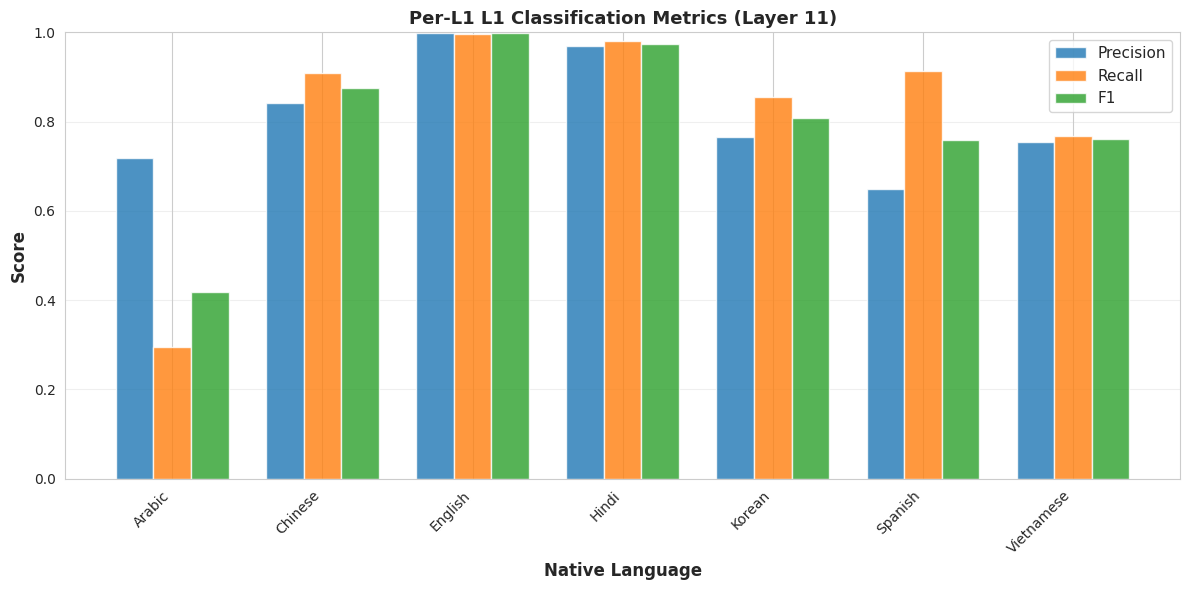

Saved: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/figures/fig1c_layerwise_per_l1_f1.png


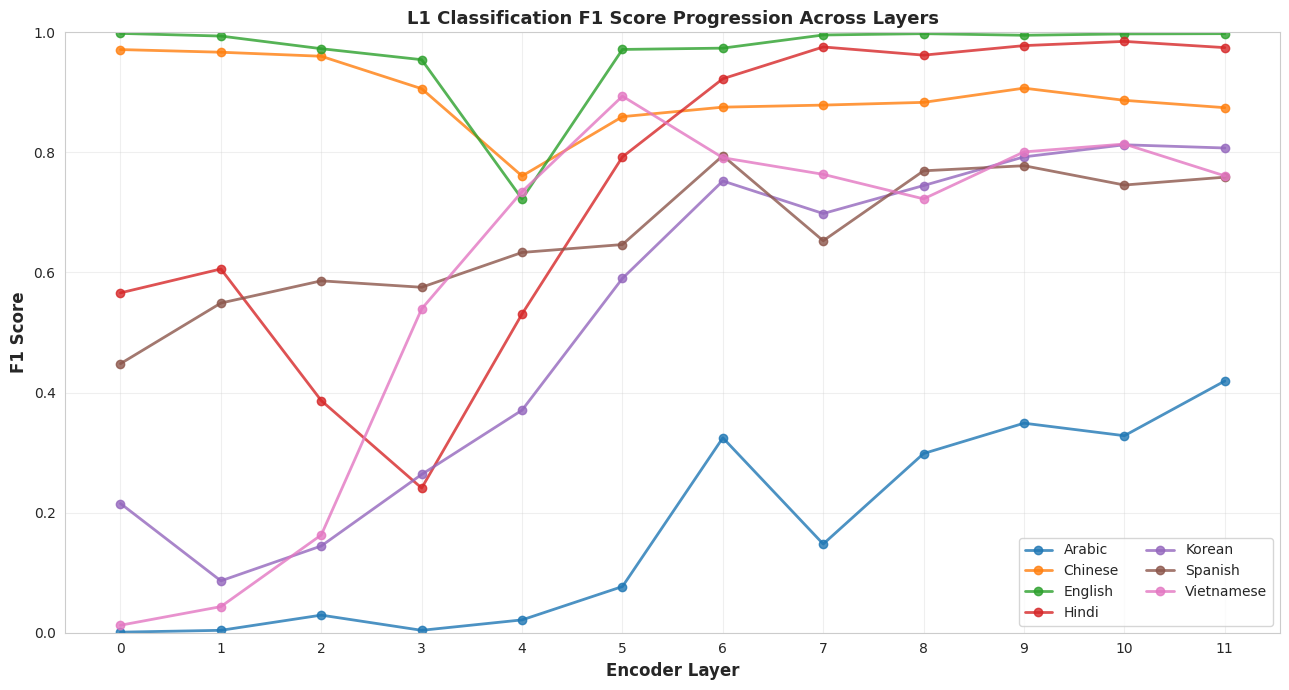

In [17]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pickle

print("Computing per-L1 probing metrics across all layers...\n")

# Check for cached results
probe_cache_path = results_dir / "e2_probe_results.pkl"
if probe_cache_path.exists():
    print(f"Loading cached probe results from: {probe_cache_path}")
    with open(probe_cache_path, 'rb') as f:
        cached_results = pickle.load(f)
    l1_acc_per_layer = cached_results['l1_acc_per_layer']
    per_layer_per_l1_results = cached_results['per_layer_per_l1_results']
    print(f"Loaded cached results for {len(l1_acc_per_layer)} layers\n")
else:
    test_utts = [u for u in utterance_embeddings if u['split'] == 'test']
    train_utts = [u for u in utterance_embeddings if u['split'] in ['train', 'dev']]

    # Store results per layer
    l1_acc_per_layer = {}
    per_layer_per_l1_results = {}

    for layer_idx in tqdm(range(WHISPER_N_ENCODER_LAYERS), desc="  Layers"):
        X_train = np.stack([u['layer_reps'][layer_idx] for u in train_utts])
        y_train = np.array([L1_GROUPS.index(u['l1']) for u in train_utts])
        X_test = np.stack([u['layer_reps'][layer_idx] for u in test_utts])
        y_test = np.array([L1_GROUPS.index(u['l1']) for u in test_utts])
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        clf = LogisticRegression(max_iter=100, tol=1e-3, random_state=42)
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
        
        # Overall accuracy
        acc = clf.score(X_test_scaled, y_test)
        l1_acc_per_layer[layer_idx] = acc
        
        # Per-L1 metrics
        precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None, labels=range(len(L1_GROUPS)))
        per_layer_per_l1_results[layer_idx] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': support,
        }

    # Cache results
    probe_cache_path.parent.mkdir(parents=True, exist_ok=True)
    with open(probe_cache_path, 'wb') as f:
        pickle.dump({'l1_acc_per_layer': l1_acc_per_layer, 'per_layer_per_l1_results': per_layer_per_l1_results}, f)
    print(f"Cached probe results to: {probe_cache_path}\n")

# Display results for final layer
target_layer = 11
print(f"L1 Classification Metrics (Layer {target_layer}):")
print(f"Overall Accuracy: {l1_acc_per_layer[target_layer]:.3f}\n")

per_l1_results = []
for i, l1 in enumerate(L1_GROUPS):
    per_l1_results.append({
        'L1': l1,
        'Precision': per_layer_per_l1_results[target_layer]['precision'][i],
        'Recall': per_layer_per_l1_results[target_layer]['recall'][i],
        'F1': per_layer_per_l1_results[target_layer]['f1'][i],
        'Support': int(per_layer_per_l1_results[target_layer]['support'][i]),
    })

df_per_l1 = pd.DataFrame(per_l1_results)
print(df_per_l1.to_string(index=False))
print(f"\nMean across L1s: P={per_layer_per_l1_results[target_layer]['precision'].mean():.3f}, "
      f"R={per_layer_per_l1_results[target_layer]['recall'].mean():.3f}, "
      f"F1={per_layer_per_l1_results[target_layer]['f1'].mean():.3f}")

# Plot per-L1 metrics at target layer
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(L1_GROUPS))
width = 0.25

precision = per_layer_per_l1_results[target_layer]['precision']
recall = per_layer_per_l1_results[target_layer]['recall']
f1 = per_layer_per_l1_results[target_layer]['f1']

ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
ax.bar(x, recall, width, label='Recall', alpha=0.8)
ax.bar(x + width, f1, width, label='F1', alpha=0.8)

ax.set_xlabel('Native Language', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Per-L1 L1 Classification Metrics (Layer {target_layer})', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(L1_GROUPS, rotation=45, ha='right')
ax.set_ylim([0, 1])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
output_path = Path(f"{results_dir}/figures/fig1b_per_l1_probe_metrics.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"\nSaved: {output_path}")
plt.show()

# Plot layerwise per-L1 F1 scores
fig, ax = plt.subplots(figsize=(13, 7))
for i, l1 in enumerate(L1_GROUPS):
    f1_scores = [per_layer_per_l1_results[layer]['f1'][i] for layer in range(WHISPER_N_ENCODER_LAYERS)]
    ax.plot(range(WHISPER_N_ENCODER_LAYERS), f1_scores, marker='o', linewidth=2, markersize=6, label=l1, alpha=0.8)

ax.set_xlabel('Encoder Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('L1 Classification F1 Score Progression Across Layers', fontsize=13, fontweight='bold')
ax.set_xticks(range(WHISPER_N_ENCODER_LAYERS))
ax.set_ylim([0, 1])
ax.legend(fontsize=10, ncol=2, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
output_path = Path(f"{results_dir}/figures/fig1c_layerwise_per_l1_f1.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

## Fig 2: UMAP visualization of latent space

Computing utterance UMAPs for layers [9, 11]...


  UMAP layers:  50%|█████     | 1/2 [00:32<00:32, 32.40s/it]

  ✓ Layer 9: UMAP shape (5600, 2)


  UMAP layers: 100%|██████████| 2/2 [00:49<00:00, 24.92s/it]

  ✓ Layer 11: UMAP shape (5600, 2)


Saved: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/figures/fig2a_umap_utterances_progression.png


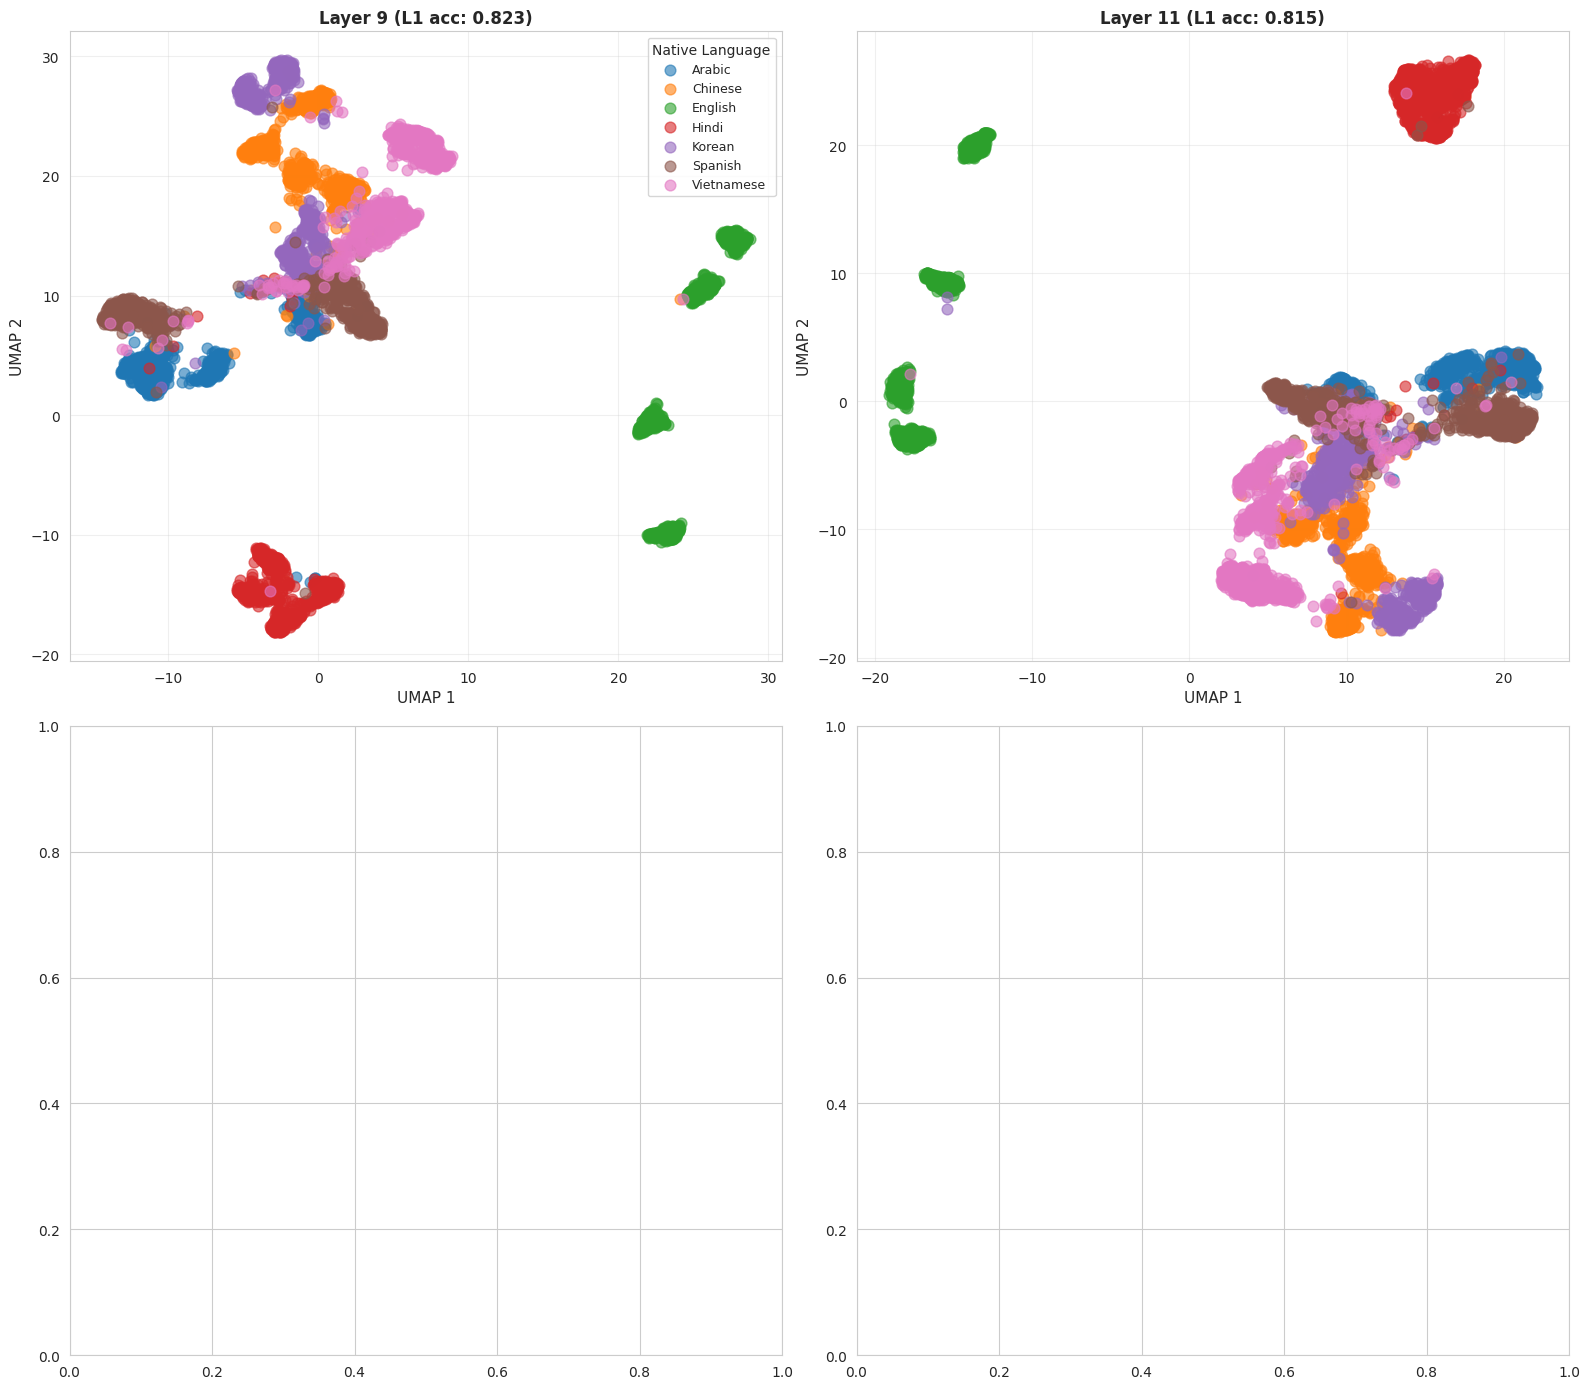

In [19]:
# Plot utterance-level UMAP progression across layers
layers_to_plot = [9, 11]
print(f"Computing utterance UMAPs for layers {layers_to_plot}...")
filtered_utts = [u for u in sampled_utts] #if u["l1"] not in ["English", "Hindi"]]
umap_utts_dict = {}
for layer_idx in tqdm(layers_to_plot, desc="  UMAP layers"):
    X_layer = np.array([u["layer_reps"][layer_idx] for u in filtered_utts])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_layer)
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=50, min_dist=0.02, spread=3)
    umap_result = reducer.fit_transform(X_scaled)
    umap_utts_dict[layer_idx] = umap_result
    print(f"  ✓ Layer {layer_idx}: UMAP shape {umap_result.shape}")

# Plot in 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

l1_colors = {l1: plt.cm.tab10(i) for i, l1 in enumerate(L1_GROUPS)}

for plot_idx, layer_idx in enumerate(layers_to_plot):
    ax = axes[plot_idx]
    umap_utt = umap_utts_dict[layer_idx]
    
    for l1 in L1_GROUPS:
        mask = np.array([u["l1"] for u in filtered_utts]) == l1
        ax.scatter(umap_utt[mask, 0], umap_utt[mask, 1], label=l1, s=60, alpha=0.6, color=l1_colors[l1])
    
    ax.set_xlabel('UMAP 1', fontsize=11)
    ax.set_ylabel('UMAP 2', fontsize=11)
    ax.set_title(f'Layer {layer_idx} (L1 acc: {l1_acc_per_layer[layer_idx]:.3f})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if plot_idx == 0:
        ax.legend(fontsize=9, loc='best', title='Native Language')

plt.tight_layout()
output_path = Path(f"{results_dir}/figures/fig2a_umap_utterances_progression.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

## Within-L1 vs Cross-L1 distances (utterance-level)

In [20]:
from scipy.spatial.distance import cosine

print("Computing utterance-level L1 separation...\n")

# For each L1, compute within-L1 distances (same utterance, different speakers)
test_utts = [u for u in utterance_embeddings if u["split"] == "test"]
test_by_l1 = {}
for u in test_utts:
    if u["l1"] not in test_by_l1:
        test_by_l1[u["l1"]] = []
    test_by_l1[u["l1"]].append(u)

within_l1_distances = []
cross_l1_distances = []

# Within-L1: same utterance text, different speakers
for l1 in test_by_l1:
    if l1 == "English":
        continue
    utts = test_by_l1[l1]
    for i in range(len(utts)):
        for j in range(i+1, len(utts)):
            suffix_i = "_".join(utts[i]["utt_id"].split("_")[1:])
            suffix_j = "_".join(utts[j]["utt_id"].split("_")[1:])
            if suffix_i == suffix_j:
                dist = cosine(utts[i]["layer_reps"][target_layer], utts[j]["layer_reps"][target_layer])
                within_l1_distances.append(dist)

# Cross-L1 vs English: same utterance text, different L1s
english_utts = {u["utt_id"]: u for u in test_utts if u["l1"] == "English"}
for l1 in test_by_l1:
    if l1 != "English":
        for u_l2 in test_by_l1[l1]:
            suffix = "_".join(u_l2["utt_id"].split("_")[1:])
            for u_en in english_utts.values():
                if suffix in u_en["utt_id"]:
                    dist = cosine(u_l2["layer_reps"][target_layer], u_en["layer_reps"][target_layer])
                    cross_l1_distances.append(dist)
                    break

print(f"Within-L1 (same utterance, different speakers): {len(within_l1_distances)} pairs")
if within_l1_distances:
    print(f"  Mean: {np.mean(within_l1_distances):.4f}, Std: {np.std(within_l1_distances):.4f}")

print(f"Cross-L1 vs English (same utterance): {len(cross_l1_distances)} pairs")
if cross_l1_distances:
    print(f"  Mean: {np.mean(cross_l1_distances):.4f}, Std: {np.std(cross_l1_distances):.4f}")

# Plot distributions
if within_l1_distances and cross_l1_distances:
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.hist(within_l1_distances, bins=30, alpha=0.6, label=f"Within-L1 (n={len(within_l1_distances)})", color='#2E86AB', edgecolor='black')
    ax.hist(cross_l1_distances, bins=30, alpha=0.6, label=f"L2 vs English (n={len(cross_l1_distances)})", color='#A23B72', edgecolor='black')
    ax.set_xlabel('Cosine Distance (Layer {target_layer})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title('Utterance-Level Distance Distributions', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    output_path = results_dir / "figures/fig3_utterance_distances.png"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\nSaved: {output_path}")
    plt.show()


Computing utterance-level L1 separation...

Within-L1 (same utterance, different speakers): 0 pairs
Cross-L1 vs English (same utterance): 6664 pairs
  Mean: 0.0115, Std: 0.0044


## Silhouette score (utterance-level)

Computing silhouette scores...

Global Silhouette Score (cosine metric): 0.2503
  Range: [-1, 1]. Closer to +1 = better L1 separation.

Per-L1 silhouette scores:
  Arabic      :  0.1235
  Chinese     :  0.1589
  English     :  0.6973
  Hindi       :  0.4216
  Korean      :  0.1885
  Spanish     :  0.0922
  Vietnamese  :  0.0524

Saved: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/figures/fig3b_silhouette_analysis.png


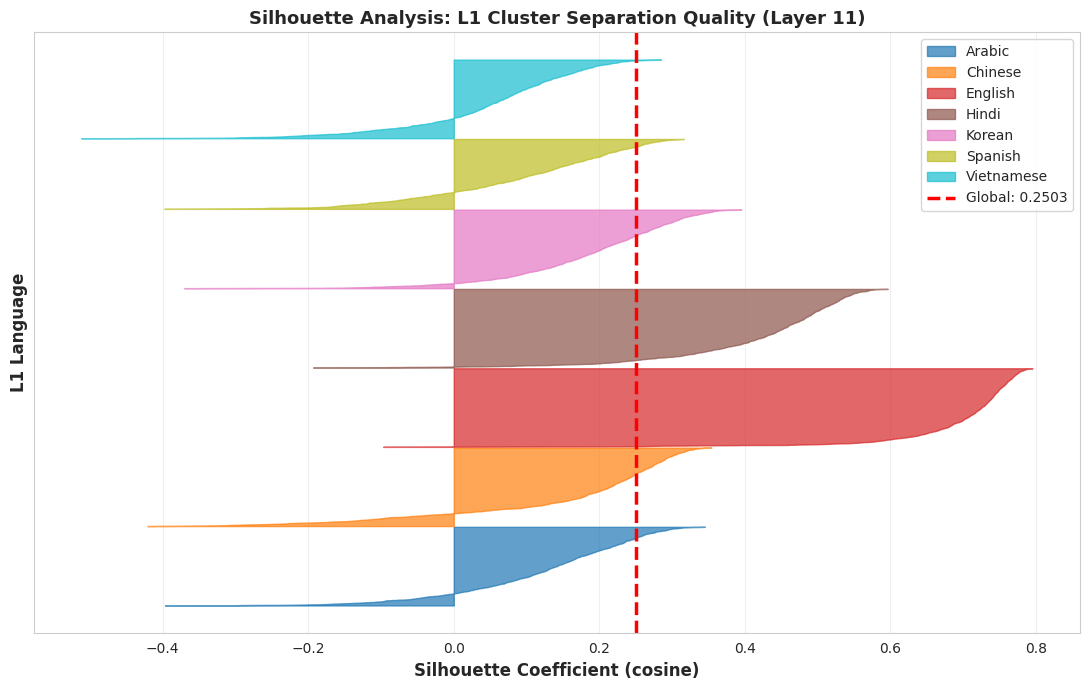

In [21]:
from sklearn.metrics import silhouette_score, silhouette_samples

print("Computing silhouette scores...\n")

# Silhouette score measures how well-separated L1 clusters are
test_utts = [u for u in utterance_embeddings if u["split"] == "test"]
X_test = np.stack([u["layer_reps"][target_layer] for u in test_utts])
y_labels = np.array([L1_GROUPS.index(u["l1"]) for u in test_utts])

# Global silhouette score (cosine metric)
sil_score = silhouette_score(X_test, y_labels, metric='cosine')
print(f"Global Silhouette Score (cosine metric): {sil_score:.4f}")
print(f"  Range: [-1, 1]. Closer to +1 = better L1 separation.")

# Per-L1 average silhouette
sil_samples = silhouette_samples(X_test, y_labels, metric='cosine')
print(f"\nPer-L1 silhouette scores:")
for i, l1 in enumerate(L1_GROUPS):
    mask = y_labels == i
    if mask.sum() > 0:
        avg_sil = sil_samples[mask].mean()
        print(f"  {l1:12s}: {avg_sil:7.4f}")

# Silhouette plot
fig, ax = plt.subplots(figsize=(11, 7))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, len(L1_GROUPS)))

for i, l1 in enumerate(L1_GROUPS):
    mask = y_labels == i
    cluster_sil = sil_samples[mask]
    cluster_sil.sort()
    
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, 
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7, label=l1)
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color="red", linestyle="--", linewidth=2.5, label=f"Global: {sil_score:.4f}")
ax.set_xlabel("Silhouette Coefficient (cosine)", fontsize=12, fontweight='bold')
ax.set_ylabel("L1 Language", fontsize=12, fontweight='bold')
ax.set_title(f"Silhouette Analysis: L1 Cluster Separation Quality (Layer {target_layer})", fontsize=13, fontweight='bold')
ax.set_yticks([])
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
output_path = results_dir / "figures/fig3b_silhouette_analysis.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"\nSaved: {output_path}")
plt.show()


## Fig 4: Displacement dimensionality and L1 clustering

In [22]:
print("Computing dimensionality analysis (L2 vs English vs Displacement)...\n")

# ===== Prepare data =====
l2_utts = [u for u in utterance_embeddings if u["l1"] != "English"]
english_utts = [u for u in utterance_embeddings if u["l1"] == "English"]

print(f"Total L2 utterances: {len(l2_utts)}")
print(f"Total English utterances: {len(english_utts)}")

# Extract raw encodings at target layer
l2_encodings = np.array([u["layer_reps"][target_layer] for u in l2_utts])  # (N_l2, 768)
english_encodings = np.array([u["layer_reps"][target_layer] for u in english_utts])  # (N_eng, 768)
all_encodings = np.vstack([l2_encodings, english_encodings])  # (N_total, 768)

print(f"L2 encodings shape: {l2_encodings.shape}")
print(f"English encodings shape: {english_encodings.shape}")
print(f"All encodings shape: {all_encodings.shape}")

# ===== Compute displacement vectors =====
# For each L2 utterance, find its matched English utterance
l2_dict = {u["utt_id"]: u for u in l2_utts}
english_dict = {u["utt_id"]: u for u in english_utts}

displacement_vecs = []
displacement_l1s = []
matched_count = 0

for l2_utt in l2_utts:
    utt_suffix = "_".join(l2_utt["utt_id"].split("_")[1:])
    matching_eng = None
    for eng_id, eng_utt in english_dict.items():
        if utt_suffix in eng_id:
            matching_eng = eng_utt
            break
    
    if matching_eng is None:
        continue
    
    l2_rep = l2_utt["layer_reps"][target_layer]
    eng_rep = matching_eng["layer_reps"][target_layer]
    disp_vec = l2_rep - eng_rep
    
    displacement_vecs.append(disp_vec)
    displacement_l1s.append(l2_utt["l1"])
    matched_count += 1

displacement_vecs = np.array(displacement_vecs)  # (N_matched, 768)
displacement_l1s = np.array(displacement_l1s)

print(f"\nMatched L2-English pairs: {matched_count}")
print(f"Displacement vectors shape: {displacement_vecs.shape}")

# ===== PCA Analysis =====
from sklearn.decomposition import PCA

print(f"\n{'='*60}")
print("PCA RESULTS")
print(f"{'='*60}\n")

pca_results = {}

# 1. PCA on all encodings (L2 + English)
pca_all = PCA()
pca_all.fit(all_encodings)
cumsum_all = np.cumsum(pca_all.explained_variance_ratio_)
n_comp_all_95 = np.argmax(cumsum_all >= 0.95) + 1

pca_results['all'] = {
    'n_samples': all_encodings.shape[0],
    'n_components_95': n_comp_all_95,
    'pca': pca_all,
    'cumsum': cumsum_all
}

# 2. PCA on L2 encodings only
pca_l2 = PCA()
pca_l2.fit(l2_encodings)
cumsum_l2 = np.cumsum(pca_l2.explained_variance_ratio_)
n_comp_l2_95 = np.argmax(cumsum_l2 >= 0.95) + 1

pca_results['l2'] = {
    'n_samples': l2_encodings.shape[0],
    'n_components_95': n_comp_l2_95,
    'pca': pca_l2,
    'cumsum': cumsum_l2
}

# 3. PCA on English encodings only
pca_eng = PCA()
pca_eng.fit(english_encodings)
cumsum_eng = np.cumsum(pca_eng.explained_variance_ratio_)
n_comp_eng_95 = np.argmax(cumsum_eng >= 0.95) + 1

pca_results['english'] = {
    'n_samples': english_encodings.shape[0],
    'n_components_95': n_comp_eng_95,
    'pca': pca_eng,
    'cumsum': cumsum_eng
}

# 4. PCA on displacement vectors
pca_disp = PCA()
pca_disp.fit(displacement_vecs)
cumsum_disp = np.cumsum(pca_disp.explained_variance_ratio_)
n_comp_disp_95 = np.argmax(cumsum_disp >= 0.95) + 1

pca_results['displacement'] = {
    'n_samples': displacement_vecs.shape[0],
    'n_components_95': n_comp_disp_95,
    'pca': pca_disp,
    'cumsum': cumsum_disp
}

# Print results
print(f"All encodings (L2 + English):     {n_comp_all_95:3d} / 768 components for 95% variance  ({pca_results['all']['n_samples']:5d} samples)")
print(f"L2 encodings only:                {n_comp_l2_95:3d} / 768 components for 95% variance  ({pca_results['l2']['n_samples']:5d} samples)")
print(f"English encodings only:           {n_comp_eng_95:3d} / 768 components for 95% variance  ({pca_results['english']['n_samples']:5d} samples)")
print(f"Displacement vectors (L2-Eng):    {n_comp_disp_95:3d} / 768 components for 95% variance  ({pca_results['displacement']['n_samples']:5d} samples)")

print(f"\nInterpretation:")
print(f"  L2 complexity:        {n_comp_l2_95} dims")
print(f"  English complexity:   {n_comp_eng_95} dims")
print(f"  Accent perturbation:  {n_comp_disp_95} dims")
if n_comp_eng_95 < n_comp_l2_95:
    print(f"  → English is SIMPLER (uses {n_comp_l2_95 - n_comp_eng_95} fewer dims)")
else:
    print(f"  → L2 is SIMPLER (uses {n_comp_eng_95 - n_comp_l2_95} fewer dims)")

if n_comp_disp_95 < min(n_comp_l2_95, n_comp_eng_95):
    print(f"  → Displacement is LOW-RANK (narrow perturbation in encoding space)")
else:
    print(f"  → Displacement is HIGH-RANK (broad perturbation)")

# Store for plotting
pca = pca_disp  # For backward compatibility with next cell


Computing dimensionality analysis (L2 vs English vs Displacement)...

Total L2 utterances: 26867
Total English utterances: 4528
L2 encodings shape: (26867, 768)
English encodings shape: (4528, 768)
All encodings shape: (31395, 768)

Matched L2-English pairs: 26867
Displacement vectors shape: (26867, 768)

PCA RESULTS

All encodings (L2 + English):     152 / 768 components for 95% variance  (31395 samples)
L2 encodings only:                165 / 768 components for 95% variance  (26867 samples)
English encodings only:           196 / 768 components for 95% variance  ( 4528 samples)
Displacement vectors (L2-Eng):    189 / 768 components for 95% variance  (26867 samples)

Interpretation:
  L2 complexity:        165 dims
  English complexity:   196 dims
  Accent perturbation:  189 dims
  → L2 is SIMPLER (uses 31 fewer dims)
  → Displacement is HIGH-RANK (broad perturbation)



Saved: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/figures/fig4_pca_comparison.png


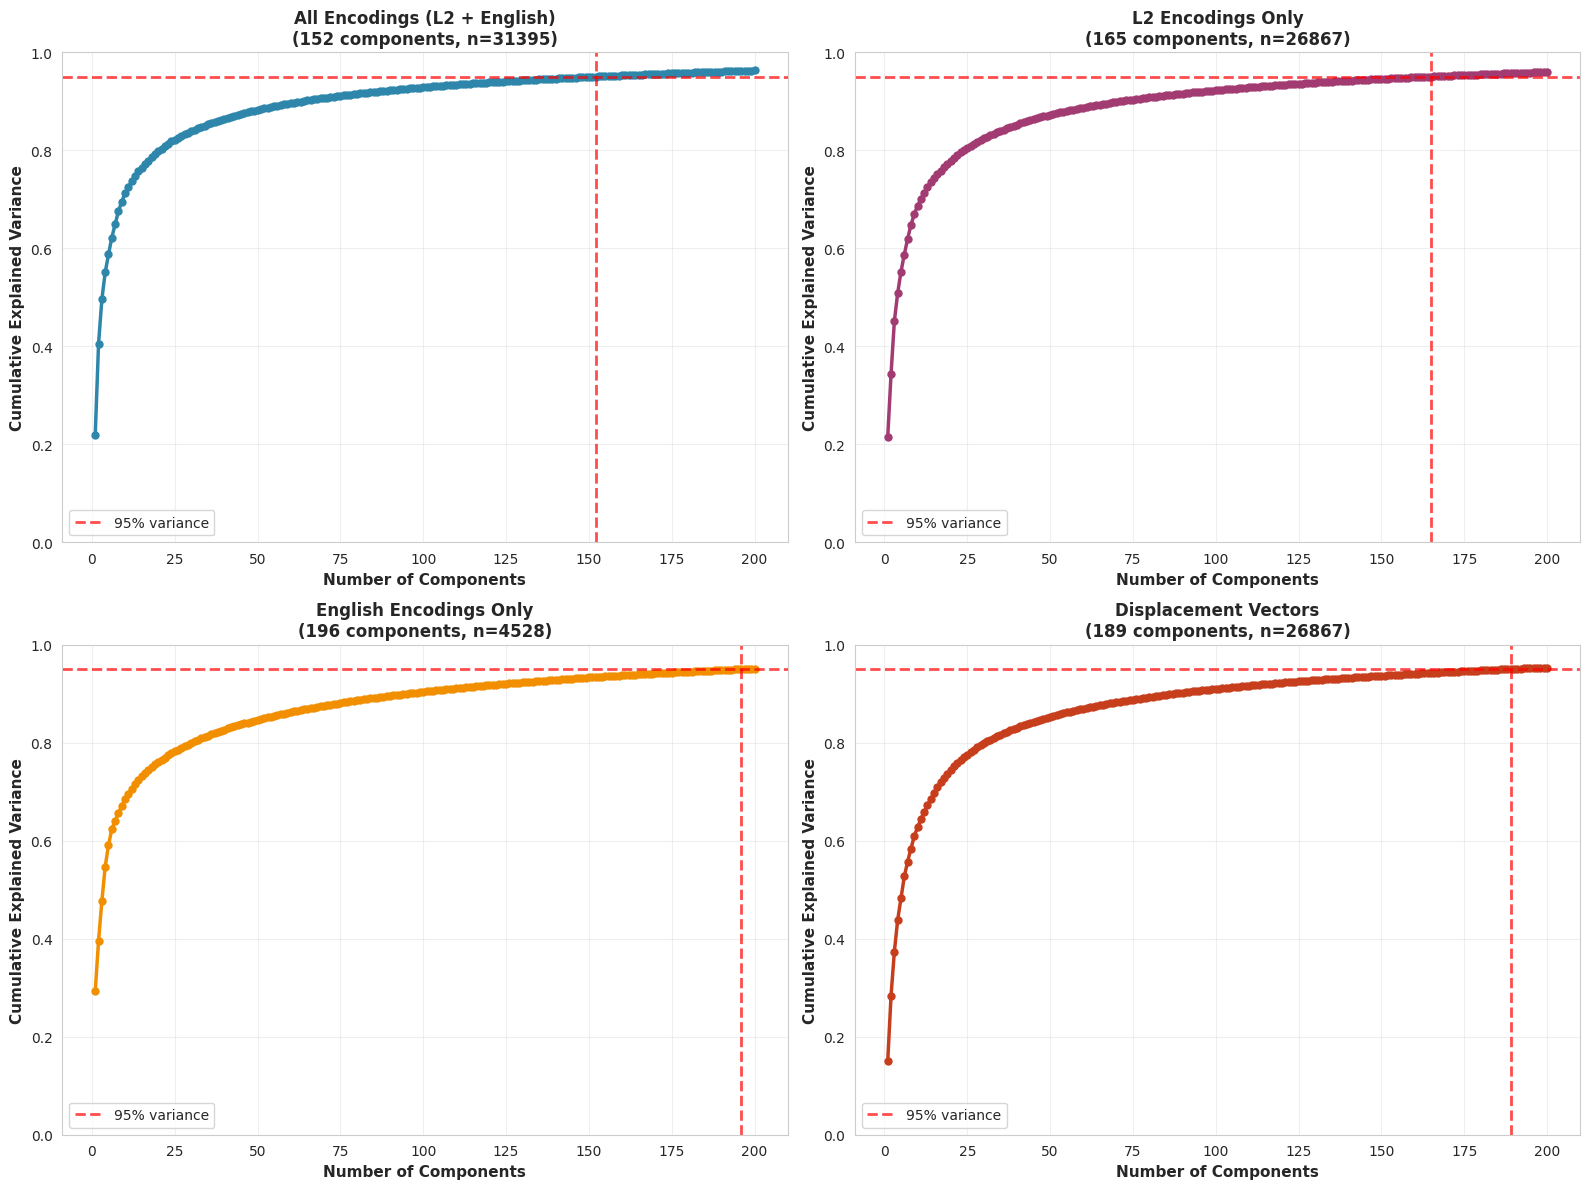

In [23]:
# Plot all PCA results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

titles = ['All Encodings (L2 + English)', 'L2 Encodings Only', 'English Encodings Only', 'Displacement Vectors']
keys = ['all', 'l2', 'english', 'displacement']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for idx, (ax, key, title, color) in enumerate(zip(axes.flat, keys, titles, colors)):
    result = pca_results[key]
    cumsum = result['cumsum']
    n_comp_95 = result['n_components_95']
    n_samples = result['n_samples']
    
    n_comps_to_plot = min(200, len(cumsum))
    ax.plot(range(1, n_comps_to_plot + 1), cumsum[:n_comps_to_plot], 
            marker='o', linewidth=2.5, markersize=5, color=color)
    ax.axhline(y=0.95, color='red', linestyle='--', linewidth=2, alpha=0.7, label='95% variance')
    ax.axvline(x=n_comp_95, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Number of Components', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cumulative Explained Variance', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\n({n_comp_95} components, n={n_samples})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    ax.legend(fontsize=10)

plt.tight_layout()
output_path = results_dir / "figures/fig4_pca_comparison.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"\nSaved: {output_path}")
plt.show()


In [ ]:
print("\n" + "="*60)
print("E2 SUMMARY")
print("="*60)
print(f"\nTarget Layer: {target_layer}")
print(f"  - L1 classification accuracy: {l1_acc_per_layer[target_layer]:.3f}")
print(f"\nL1 Clustering (Fig 2):")
print(f"  - Utterance-level embeddings show spatial structure")
print(f"  - Within-L1 and cross-L1 distances are quantified")
print(f"  - Silhouette scores measure L1 cluster separation")
print(f"\nDisplacement Analysis:")
print(f"  - Displacement vectors show lower intrinsic dimensionality")
print(f"  - Suggests accent is low-rank perturbation in latent space")


CORRELATION: Clustering vs Model WER

Loaded predictions from: whisfusion_finetuned_predictions.csv
Columns: ['utterance_id', 'speaker', 'l1', 'wav_path', 'domain', 'text', 'prediction', 'reference_norm', 'prediction_norm', 'ref_num_words', 'utt_wer', 'utt_mer', 'utt_per']

Per-L1 WER:
        L1      WER  WER_std  WER_count
    Arabic 0.053960 0.103235       1132
   Chinese 0.096467 0.135948       1130
   English 0.035438 0.075835       1131
     Hindi 0.033157 0.075877       1132
    Korean 0.027751 0.068492       1131
   Spanish 0.141780 0.166733       1007
Vietnamese 0.151548 0.165144       1132

Combined metrics:
        L1      WER  WER_std  WER_count  Silhouette  Probe_F1
    Arabic 0.053960 0.103235       1132    0.123462  0.419274
   Chinese 0.096467 0.135948       1130    0.158863  0.874521
   English 0.035438 0.075835       1131    0.697298  0.997791
     Hindi 0.033157 0.075877       1132    0.421561  0.974539
    Korean 0.027751 0.068492       1131    0.188511  0.807355
 

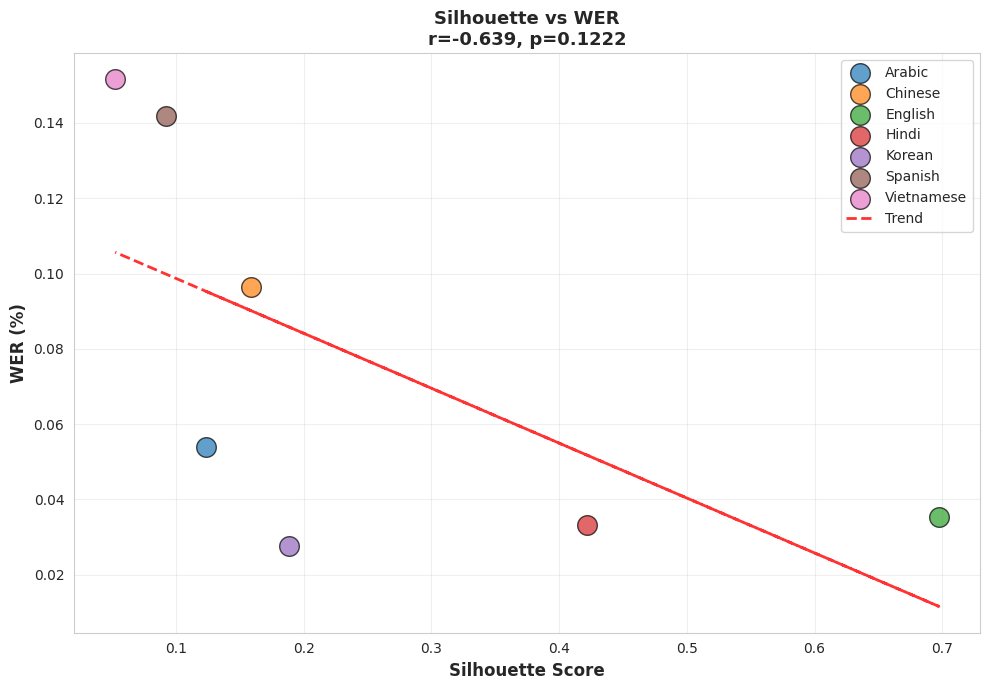

Saved: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/figures/fig5b_probe_f1_vs_wer.png


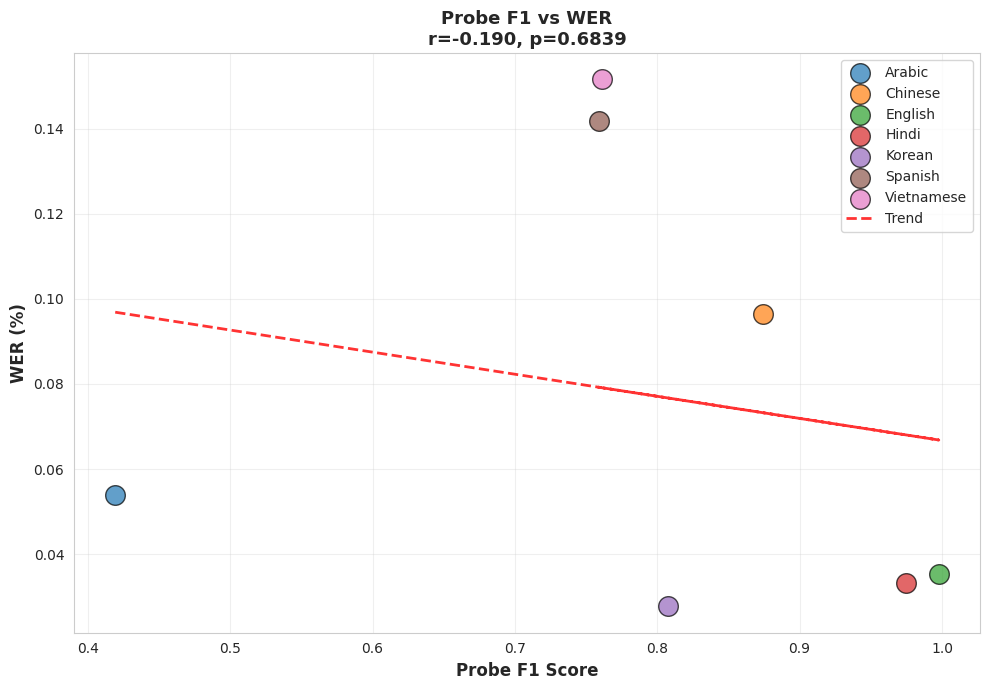

Saved: /rds/general/user/tsv22/home/accent-robust-asr/src/analysis/results/figures/fig5c_multi_metric_comparison.png



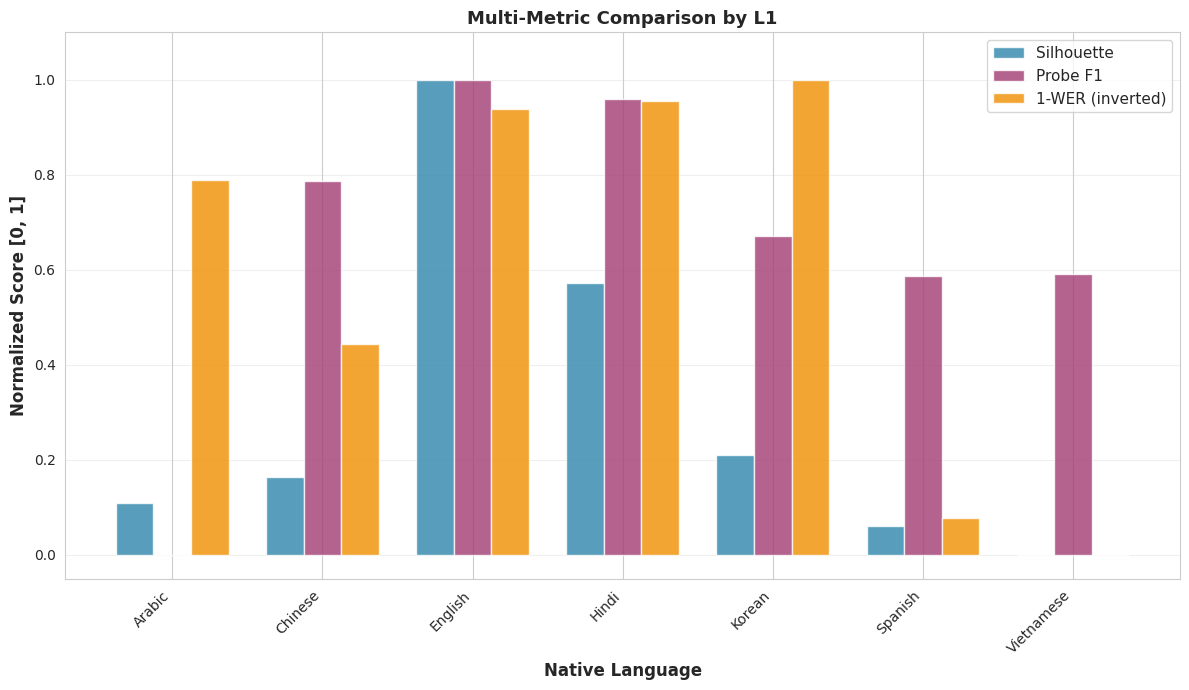

In [ ]:
def normalize_minmax(series, invert=False):
    """Normalize series to [0, 1] range using min-max scaling."""
    norm = (series - series.min()) / (series.max() - series.min())
    return 1 - norm if invert else norm

print("\n" + "="*60)
print("CORRELATION: Clustering vs Model WER")
print("="*60 + "\n")

# ===== CONFIG: SWAP MODEL HERE =====
model_csv = root / "results" / "model_perf_comparison" / "baseline_predictions.csv"
# Swap to: baseline_predictions.csv for Whisper baseline

if not model_csv.exists():
    print(f"⚠ Model predictions not found: {model_csv}")
else:
    df_pred = pd.read_csv(model_csv)
    print(f"Loaded predictions from: {model_csv.name}")
    print(f"Columns: {list(df_pred.columns)}\n")
    
    # Compute per-L1 WER (average across all utterances)
    if 'speaker' in df_pred.columns and 'utt_wer' in df_pred.columns:
        # L1 is already in the CSV
        
        # Group by L1 and compute mean WER
        wer_by_l1 = df_pred.groupby('l1')['utt_wer'].agg(['mean', 'std', 'count']).reset_index()
        wer_by_l1.columns = ['L1', 'WER', 'WER_std', 'WER_count']
        
        print("Per-L1 WER:")
        print(wer_by_l1.to_string(index=False))
        print()
        
        # Collect clustering metrics per L1
        sil_by_l1 = pd.DataFrame([
            {'L1': l1, 'Silhouette': sil_samples[y_labels == i].mean()}
            for i, l1 in enumerate(L1_GROUPS)
            if (y_labels == i).sum() > 0
        ])
        
        probe_f1_by_l1 = pd.DataFrame([
            {'L1': l1, 'Probe_F1': per_layer_per_l1_results[target_layer]['f1'][i]}
            for i, l1 in enumerate(L1_GROUPS)
        ])
        
        # Merge all metrics (outer join to preserve all L1s)
        metrics_df = wer_by_l1.merge(sil_by_l1, on='L1', how='outer').merge(probe_f1_by_l1, on='L1', how='outer')
        
        print("Combined metrics:")
        print(metrics_df.to_string(index=False))
        print()
        
        # Compute correlations (only on rows with all metrics)
        valid_mask = metrics_df[['WER', 'Silhouette', 'Probe_F1']].notna().all(axis=1)
        metrics_valid = metrics_df[valid_mask]
        
        if len(metrics_valid) < 3:
            print(f"⚠ Warning: Only {len(metrics_valid)} L1s have complete data")
        
        r_sil_wer, p_sil_wer = pearsonr(metrics_valid['Silhouette'], metrics_valid['WER'])
        rho_sil_wer, p_sil_wer_rho = spearmanr(metrics_valid['Silhouette'], metrics_valid['WER'])
        
        r_f1_wer, p_f1_wer = pearsonr(metrics_valid['Probe_F1'], metrics_valid['WER'])
        rho_f1_wer, p_f1_wer_rho = spearmanr(metrics_valid['Probe_F1'], metrics_valid['WER'])
        
        print(f"Correlation: Silhouette vs WER (n={len(metrics_valid)})")
        print(f"  Pearson r = {r_sil_wer:.3f}, p = {p_sil_wer:.4f}")
        print(f"  Spearman ρ = {rho_sil_wer:.3f}, p = {p_sil_wer_rho:.4f}\n")
        
        print(f"Correlation: Probe F1 vs WER (n={len(metrics_valid)})")
        print(f"  Pearson r = {r_f1_wer:.3f}, p = {p_f1_wer:.4f}")
        print(f"  Spearman ρ = {rho_f1_wer:.3f}, p = {p_f1_wer_rho:.4f}\n")
        
        # ===== PLOTS: Create separate figures =====
        # Create color map for L1s
        l1_colors = {l1: plt.cm.tab10(i % 10) for i, l1 in enumerate(L1_GROUPS)}

        # Plot A: Silhouette vs WER
        fig, ax = plt.subplots(figsize=(10, 7))
        for l1 in metrics_valid['L1'].unique():
            mask = metrics_valid['L1'] == l1
            ax.scatter(metrics_valid[mask]['Silhouette'], metrics_valid[mask]['WER'],
                      s=200, alpha=0.7, color=l1_colors[l1], label=l1, edgecolors='black', linewidth=1)
        z = np.polyfit(metrics_valid['Silhouette'], metrics_valid['WER'], 1)
        p = np.poly1d(z)
        ax.plot(metrics_valid['Silhouette'], p(metrics_valid['Silhouette']), "r--", linewidth=2, alpha=0.8, label='Trend')
        ax.set_xlabel('Silhouette Score', fontsize=12, fontweight='bold')
        ax.set_ylabel('WER (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'Silhouette vs WER\nr={r_sil_wer:.3f}, p={p_sil_wer:.4f}', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10, loc='best')
        plt.tight_layout()
        output_path = results_dir / "figures/fig5a_silhouette_vs_wer.png"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}")
        plt.show()

        # Plot B: Probe F1 vs WER
        fig, ax = plt.subplots(figsize=(10, 7))
        for l1 in metrics_valid['L1'].unique():
            mask = metrics_valid['L1'] == l1
            ax.scatter(metrics_valid[mask]['Probe_F1'], metrics_valid[mask]['WER'],
                      s=200, alpha=0.7, color=l1_colors[l1], label=l1, edgecolors='black', linewidth=1)
        z = np.polyfit(metrics_valid['Probe_F1'], metrics_valid['WER'], 1)
        p = np.poly1d(z)
        ax.plot(metrics_valid['Probe_F1'], p(metrics_valid['Probe_F1']), "r--", linewidth=2, alpha=0.8, label='Trend')
        ax.set_xlabel('Probe F1 Score', fontsize=12, fontweight='bold')
        ax.set_ylabel('WER (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'Probe F1 vs WER\nr={r_f1_wer:.3f}, p={p_f1_wer:.4f}', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10, loc='best')
        plt.tight_layout()
        output_path = results_dir / "figures/fig5b_probe_f1_vs_wer.png"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}")
        plt.show()

        # Plot C: Multi-metric grouped bars (only rows with complete data)
        fig, ax = plt.subplots(figsize=(12, 7))
        metrics_df_norm = metrics_valid.copy()
        metrics_df_norm['Silhouette_norm'] = normalize_minmax(metrics_df_norm['Silhouette'])
        metrics_df_norm['Probe_F1_norm'] = normalize_minmax(metrics_df_norm['Probe_F1'])
        metrics_df_norm['WER_inverted'] = normalize_minmax(metrics_df_norm['WER'], invert=True)

        x = np.arange(len(metrics_df_norm))
        width = 0.25

        ax.bar(x - width, metrics_df_norm['Silhouette_norm'], width, label='Silhouette', alpha=0.8, color='#2E86AB')
        ax.bar(x, metrics_df_norm['Probe_F1_norm'], width, label='Probe F1', alpha=0.8, color='#A23B72')
        ax.bar(x + width, metrics_df_norm['WER_inverted'], width, label='1-WER (inverted)', alpha=0.8, color='#F18F01')

        ax.set_xlabel('Native Language', fontsize=12, fontweight='bold')
        ax.set_ylabel('Normalized Score [0, 1]', fontsize=12, fontweight='bold')
        ax.set_title('Multi-Metric Comparison by L1', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(metrics_df_norm['L1'], rotation=45, ha='right')
        ax.set_ylim([-0.05, 1.1])
        ax.legend(fontsize=11, loc='best')
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        output_path = results_dir / "figures/fig5c_multi_metric_comparison.png"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}\n")
        plt.show()
    else:
        print(f"⚠ Expected columns not found. Available: {list(df_pred.columns)}")